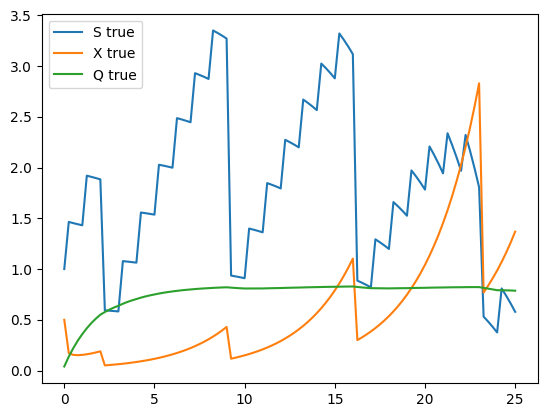

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Use the repository's Unscented KF
from pykalman import UnscentedKalmanFilter

# For reproducibility
np.random.seed(1)

# Simulation time
dt = 0.25
T = 25.0
times = np.arange(0, T + dt, dt)
n_steps = len(times)

# Droop model parameters (example values)
mu_max = 0.5      # max specific growth rate (1/day)
Q0 = 0.25         # minimum quota
rho_max = 0.3     # max uptake rate (1/day)
K_s = 0.1         # half-saturation constant for uptake

# Pulse settings
feed_period = 1.0           # days between feed pulses
feed_amplitude = 0.5        # amount of substrate added at each feed pulse

harvest_period = 7.0        # days between harvest events
harvested_fraction = 0.75   # fraction of biomass removed at harvest (0-1)
harvest_phase = 2.0         # offset so feeding and harvest can be out of phase

def mu_of_Q(Q):
    return mu_max * (1.0 - Q0 / Q)

def rho_of_S(S):
    return rho_max * S / (K_s + S)

def droop_rhs(state):
    # state: [S, X, Q]
    S, X, Q = state
    mu = mu_of_Q(Q)
    rho = rho_of_S(S)
    dX = mu * X
    dQ = rho - mu * Q
    dS = -rho * X
    return np.array([dS, dX, dQ])

def apply_pulses(state, t):
    S, X, Q = state.copy()
    # Feed pulse at multiples of feed_period
    if ((t % feed_period) < dt) or np.isclose((t % feed_period), 0.0, atol=dt/2):
        S = S + feed_amplitude
    # Harvest pulse
    if (((t - harvest_phase) % harvest_period) < dt) or np.isclose(((t - harvest_phase) % harvest_period), 0.0, atol=dt/2):
        X = X - harvested_fraction * X
        S = S - harvested_fraction * S
    return np.array([S, X, Q])

def simulate_true(x0):
    traj = np.zeros((n_steps, 3))
    traj[0] = x0.copy()
    for k in range(1, n_steps):
        t_prev = times[k-1]
        x = traj[k-1].copy()
        # apply pulses at the start of the step
        x = apply_pulses(x, t_prev)
        # Euler integration
        x = x + dt * droop_rhs(x)
        traj[k] = x
    return traj

x0_true = np.array([1.0, 0.5, 0.04])   # [S, X, Q]
true_traj = simulate_true(x0_true)

plt.plot(times, true_traj[:, 0], label='S true', color='C0')
plt.plot(times, true_traj[:, 1], label='X true', color='C1')
plt.plot(times, true_traj[:, 2], label='Q true', color='C2')
plt.legend()
plt.show()

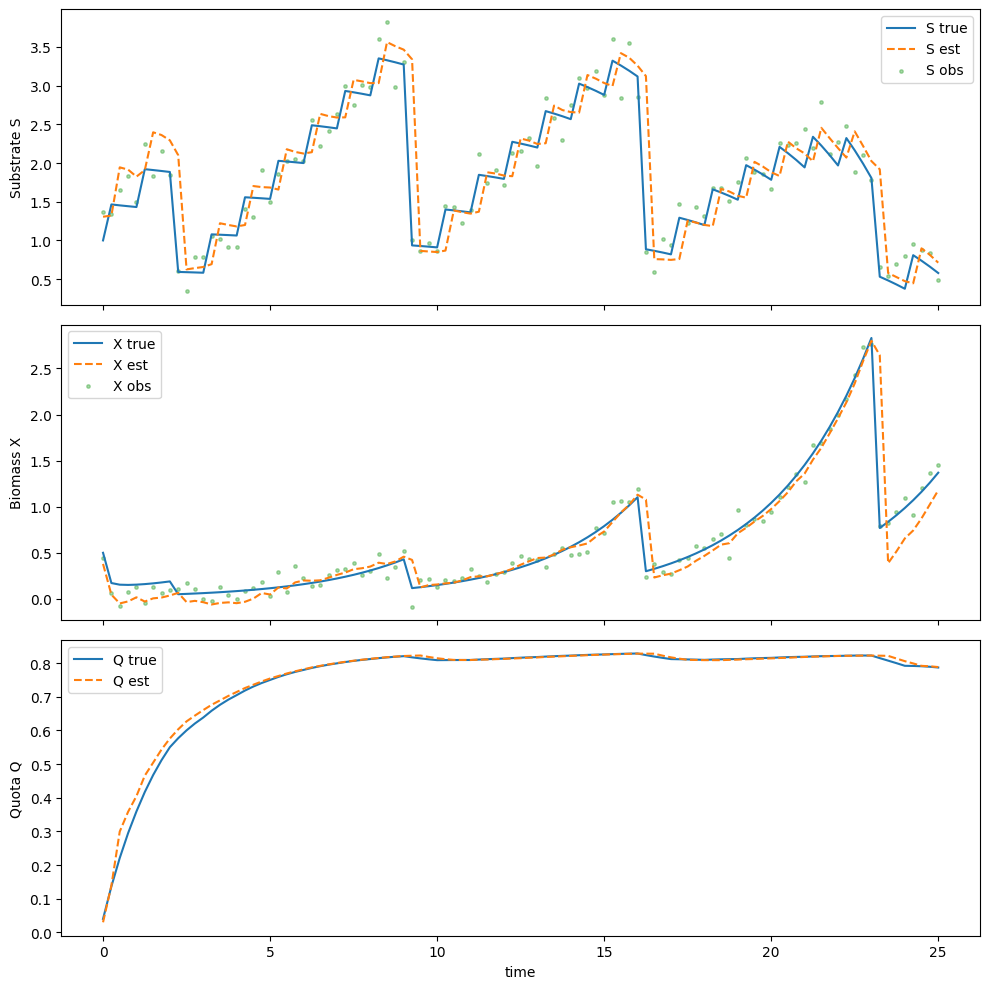

In [ ]:
import numpy as np

def make_jump_offsets_from_traj(traj, times, apply_pulses):
    """
    Returns an array of jump offsets with the same shape as traj.

    traj: array shape (n_steps, n_dim) with states at times[i]
    times: array of length n_steps
    apply_pulses: function(state, t) -> state after pulses at time t

    Note: simulate_true applies pulses at t_prev = times[k-1] before
    integrating to traj[k]. To reproduce that behavior we put the
    offset for the transition (k-1 -> k) into offsets[k].
    offsets[0] will be zeros (no transition into the initial state).
    """
    n_steps, n_dim = traj.shape
    offsets = np.zeros_like(traj)
    for k in range(1, n_steps):
        t_prev = times[k-1]
        x_prev = traj[k-1].copy()
        x_after = apply_pulses(x_prev.copy(), t_prev)
        offsets[k] = x_after - x_prev
    return offsets

# Generate jump_offsets from your true trajectory:
jump_offsets = make_jump_offsets_from_traj(true_traj, times, apply_pulses)

# Observations: measure S and X
meas_dim = 2
R_S = 0.05   # variance
R_X = 0.01

R = np.diag([R_S, R_X])
zs = np.zeros((n_steps, meas_dim))
for k in range(n_steps):
    S_true, X_true, Q_true = true_traj[k]
    zs[k, 0] = S_true + np.random.normal(0, np.sqrt(R_S))
    zs[k, 1] = X_true + np.random.normal(0, np.sqrt(R_X))


# state dimension
dim_x = 3
dim_z = meas_dim

# small additive process noise covariance (tune as needed)
Q = np.diag([1e-4, 1e-4, 1e-6])

# Observation covariance (already set)
R = np.diag([R_S, R_X])

# Create a list of transition and observation functions, one per time step.
# transition_functions[t] is used to go from time t to t+1, so length = n_steps - 1
transition_functions = []
for k in range(n_steps - 1):
    t = times[k]
    def make_f(t_local):
        def f(state, noise):
            # integrate dt, then add process noise.
            x = state.copy()
            # x = apply_pulses(x, t_local)
            x = x + dt * droop_rhs(x)
            # additive noise (assumed to be same shape as state)
            return x + noise
        return f
    transition_functions.append(make_f(t))

# observation_functions for each time index (length = n_steps)
observation_functions = []
for k in range(n_steps):
    t = times[k]
    def make_g(t_local):
        def g(state, noise):
            # we observe S and X (first two components)
            S, X, Q_ = state
            z = np.array([S, X], dtype=float)
            # add observation noise if provided, then enforce non-negative observations
            z_noisy = z + (noise if noise is not None else 0.0)
            return np.clip(z_noisy, 0.0, np.inf)
        return g
    observation_functions.append(make_g(t))


# Initial filter guess
initial_mean = np.array([0.8, 0.4, 0.03])
initial_cov = np.diag([0.5, 0.2, 0.01])

# Create the UnscentedKalmanFilter from pykalman.
ukf = UnscentedKalmanFilter(
    transition_functions,
    observation_functions,
    Q,
    R,
    initial_mean,
    initial_cov,
    random_state=0,
    jump_offsets=jump_offsets
)

# Run the filter
filtered_means, filtered_covs = ukf.filter(zs)


estimates = filtered_means  # shape (n_steps, 3)

fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axs[0].plot(times, true_traj[:, 0], label='S true', color='C0')
axs[0].plot(times, estimates[:, 0], '--', label='S est', color='C1')
axs[0].scatter(times, zs[:, 0], s=6, alpha=0.4, label='S obs', color='C2')
axs[0].set_ylabel('Substrate S'); axs[0].legend()

axs[1].plot(times, true_traj[:, 1], label='X true', color='C0')
axs[1].plot(times, estimates[:, 1], '--', label='X est', color='C1')
axs[1].scatter(times, zs[:, 1], s=6, alpha=0.4, label='X obs', color='C2')
axs[1].set_ylabel('Biomass X'); axs[1].legend()

axs[2].plot(times, true_traj[:, 2], label='Q true', color='C0')
axs[2].plot(times, estimates[:, 2], '--', label='Q est', color='C1')
axs[2].set_ylabel('Quota Q'); axs[2].set_xlabel('time'); axs[2].legend()

plt.tight_layout()
plt.show()

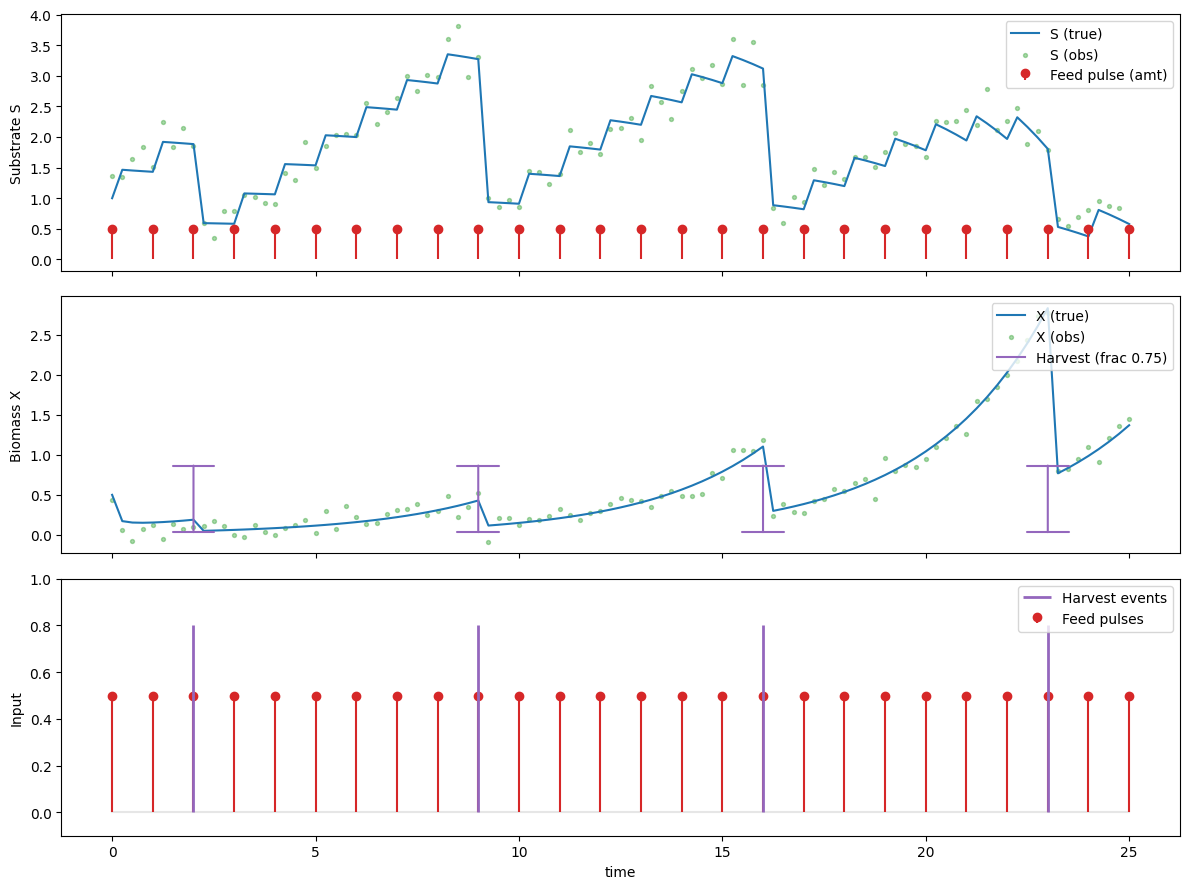

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Compute pulse times ---
# feed pulses at multiples of feed_period
feed_times = times[np.isclose(times % feed_period, 0.0, atol=dt/2) | (times % feed_period < dt)]
feed_vals = np.full(feed_times.shape, feed_amplitude)

# harvest pulses at multiples of harvest_period offset by harvest_phase
harvest_times = times[
    np.isclose((times - harvest_phase) % harvest_period, 0.0, atol=dt/2)
    | ((times - harvest_phase) % harvest_period < dt)
]
# For plotting we mark harvest events as vertical markers; magnitude as fraction removed
harvest_vals = np.full(harvest_times.shape, harvested_fraction)

# --- Plot ---
fig, ax = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# Substrate: true, observed, feed pulses
ax[0].plot(times, true_traj[:, 0], label="S (true)", color="C0")
if zs.shape[1] == 2:  # measured S in column 0
    ax[0].scatter(times, zs[:, 0], s=8, alpha=0.4, label="S (obs)", color="C2")
ax[0].stem(feed_times, feed_vals, linefmt="C3-", markerfmt="C3o", basefmt=" ", label="Feed pulse (amt)")
ax[0].set_ylabel("Substrate S")
ax[0].legend(loc="upper right")

# Biomass: true, observed, harvest pulses
ax[1].plot(times, true_traj[:, 1], label="X (true)", color="C0")
if zs.shape[1] == 2:  # measured X in column 1
    ax[1].scatter(times, zs[:, 1], s=8, alpha=0.4, label="X (obs)", color="C2")
# mark harvest events with downward arrows
for ht, hv in zip(harvest_times, harvest_vals):
    ax[1].annotate(
        "", xy=(ht, 0), xytext=(ht, plt.ylim()[1] * 0.9),
        arrowprops=dict(arrowstyle="|-|,widthA=1.5,widthB=1.5", color="C4", lw=1.5),
        va="top",
    )
# add a legend entry for harvest markers (dummy line)
ax[1].plot([], [], color="C4", lw=1.5, label=f"Harvest (frac {harvested_fraction:.2f})")
ax[1].set_ylabel("Biomass X")
ax[1].legend(loc="upper right")

# Inputs summary: compact timeline of pulses
ax[2].plot(times, np.zeros_like(times), color="0.9")  # baseline
ax[2].stem(feed_times, feed_vals, linefmt="C3-", markerfmt="C3o", basefmt=" ", label="Feed pulses")
ax[2].vlines(harvest_times, ymin=0, ymax=0.8, color="C4", lw=2, label="Harvest events")
ax[2].set_ylim(-0.1, max(feed_vals.max() * 1.2, 1.0))
ax[2].set_ylabel("Input")
ax[2].set_xlabel("time")
ax[2].legend(loc="upper right")

plt.tight_layout()
plt.show()